# QUY HOẠCH TUYẾN TÍNH — CHƯƠNG 1
### Phương pháp hình học và phương pháp đơn hình (đơn hình, Big-M, hai pha, đơn hình đối ngẫu) — chạy trên Google Colab

Mỗi lời giải **in đầy đủ bảng đơn hình của từng vòng lặp** (cơ sở, hệ số $c_B$, phương án, $\Delta_j$, tỉ số $\theta$, biến vào/ra, phần tử trục) và **kiểm chứng bằng `scipy.optimize.linprog`**.

## Cách dùng
1. Chạy **Mục 1 — Bộ giải** trước (Runtime ▸ Run all, hoặc chạy lần lượt hai ô code của Mục 1).
2. Chạy ô code của bài cần xem. Muốn giải bài khác: sửa `c`, `A`, `b`, cơ sở xuất phát ngay trong ô đó.
3. Dữ liệu có thể nhập phân số dạng chuỗi, ví dụ `'1/2'`. Hệ số phạt Big-M viết là `M` (ký hiệu, không thay bằng số).

## Mục lục
- [1. Bộ giải (chạy trước)](#engine)
- [2. Phương pháp đơn hình — Bài 15 & 16](#donhinh)
- [3. Bài toán M (Big-M) — Bài 14](#bigm14)
- [4. Bài 2.4 — giải bằng 4 phương pháp](#bai24)
    - [4.1. Phương pháp hình học](#hinhhoc)
    - [4.2. Phương pháp đơn hình đối ngẫu](#doingau)
    - [4.3. Phương pháp Big-M](#bigm24)
    - [4.4. Phương pháp hai pha](#haipha)
    - [4.5. So sánh bốn phương pháp](#sosanh)
- [5. Ghi chú phương pháp](#ghichu)

> 📝 Sau khi dùng thử, xin góp ý qua [Phiếu đánh giá sản phẩm](https://docs.google.com/forms/d/e/1FAIpQLScNqxvL5WIb8PxsOMvBbOrmmGTwV56bMyRV8-Nb_2Zvj225iw/viewform) (khoảng 5 phút).

> **Nhật ký sửa đổi so với phiên bản trước**
> 1. **Bài 2.4:** đề yêu cầu *tối thiểu* 1 400 đơn vị calo nên ràng buộc đúng là $4x_1+4x_2 \ge 1400$ (bản cũ dùng $\le$). Đáp án đúng: $x_1=50,\ x_2=300,\ f_{min}=276\,000$ (bản cũ: $(100;200)$, $264\,000$). Miền nghiệm **không bị chặn**; các đỉnh được **tính tự động** thay vì nhập tay.
> 2. **Bài 14:** bảng cuối còn biến nhân tạo $x_7 = 3/4 > 0$ ⇒ bài toán gốc **vô nghiệm** (bản cũ in sai $f_{min}=2700$ do dùng nhầm hàm mục tiêu của Bài 2.4).
> 3. **M là ký hiệu:** $\Delta_j$ hiện dạng `5M-3`, không còn các số như `49999997`.
> 4. **Mục 4.2** nay là **đơn hình đối ngẫu thật** (phù hợp vì các ràng buộc đều dạng $\ge$).
> 5. Gom các hàm trùng lặp về một bộ giải chung; thêm kiểm chứng `linprog` cho mọi bài; hàm hai pha xử lý được trường hợp biến nhân tạo còn trong cơ sở ở mức 0.

<a name="engine"></a>

## 1. Bộ giải *(chạy hai ô này trước tiên)*

**Ô 1.1 — Bộ giải đơn hình** (đơn hình, Big-M, hai pha, đối ngẫu, kiểm chứng).

In [1]:
# ======================================================================
# BỘ GIẢI ĐƠN HÌNH DẠNG BẢNG (bài toán MIN) – dùng chung cho cả notebook
#   don_hinh(...)          : đơn hình / bài toán M (Big-M) – M là KÝ HIỆU, không thay bằng số
#   hai_pha(...)           : phương pháp hai pha
#   don_hinh_doi_ngau(...) : phương pháp đơn hình đối ngẫu
#   kiem_chung(...)        : đối chiếu kết quả với scipy.optimize.linprog
# Mọi phép tính dùng phân số chính xác (fractions.Fraction).
# ======================================================================
from fractions import Fraction as Fr
import numpy as np
import pandas as pd
from scipy.optimize import linprog

def _fr(v): return v if isinstance(v, Fr) else Fr(str(v))

class SoM:
    """Số dạng a*M + b (M dương vô cùng lớn). So sánh: so a trước, rồi so b."""
    __slots__ = ("a", "b")
    def __init__(self, a=0, b=0): self.a, self.b = _fr(a), _fr(b)
    @staticmethod
    def of(v): return v if isinstance(v, SoM) else SoM(0, v)
    def __add__(s, o): o = SoM.of(o); return SoM(s.a + o.a, s.b + o.b)
    __radd__ = __add__
    def __sub__(s, o): o = SoM.of(o); return SoM(s.a - o.a, s.b - o.b)
    def __rsub__(s, o): return SoM.of(o) - s
    def __mul__(s, k): k = _fr(k); return SoM(s.a * k, s.b * k)
    __rmul__ = __mul__
    def __truediv__(s, k): k = _fr(k); return SoM(s.a / k, s.b / k)
    def _k(s): return (s.a, s.b)
    def __lt__(s, o): return s._k() < SoM.of(o)._k()
    def __le__(s, o): return s._k() <= SoM.of(o)._k()
    def __gt__(s, o): return s._k() > SoM.of(o)._k()
    def __ge__(s, o): return s._k() >= SoM.of(o)._k()
    def __eq__(s, o): return s._k() == SoM.of(o)._k()
    def __hash__(s): return hash(s._k())
    def __str__(s):
        if s.a == 0: return str(s.b)
        m = "M" if s.a == 1 else ("-M" if s.a == -1 else f"{s.a}M")
        if s.b == 0: return m
        return m + (f"+{s.b}" if s.b > 0 else f"{s.b}")
    __repr__ = __str__

M = SoM(1, 0)

def _p(v):
    t = str(v)
    return f"({t})" if ("/" in t or t.startswith("-") or "M" in t) else t

def _in_bang(vong, A, b, c, co_so, ten):
    m, n = A.shape
    cB = [c[j] for j in co_so]
    f = sum((cB[i] * b[i] for i in range(m)), SoM())
    delta = [sum((cB[i] * A[i, j] for i in range(m)), SoM()) - c[j] for j in range(n)]
    rows = [[ten[co_so[i]], str(cB[i]), str(b[i])] + [str(A[i, j]) for j in range(n)] for i in range(m)]
    rows.append(["Δj", "", str(f)] + [str(d) for d in delta])
    df = pd.DataFrame(rows, columns=["Cơ sở", "cB", "Phương án"] + ten)
    print(f"\n--- BẢNG {vong} ---"); print(df.to_string(index=False))
    return f, delta

def _xoay(A, b, co_so, r, s):
    m = A.shape[0]; piv = A[r, s]
    A[r, :] = A[r, :] / piv; b[r] = b[r] / piv
    for i in range(m):
        if i != r and A[i, s] != 0:
            k = A[i, s]; A[i, :] = A[i, :] - k * A[r, :]; b[i] = b[i] - k * b[r]
    co_so[r] = s

def _lap(A, b, c, co_so, ten, max_vong=100):
    """Lặp đơn hình cho bài toán MIN. Trả về ('toi_uu'|'khong_bi_chan', f)."""
    m, n = A.shape; vong = 1
    while True:
        f, delta = _in_bang(vong, A, b, c, co_so, ten)
        vao_ds = [j for j in range(n) if delta[j] > 0 and j not in co_so]
        if not vao_ds:
            print("=> Mọi Δj ≤ 0: phương án hiện tại là TỐI ƯU."); return "toi_uu", f
        # quy tắc Dantzig (Δ lớn nhất); sau nhiều vòng chuyển sang quy tắc Bland để tránh xoay vòng
        s = min(vao_ds) if vong > max_vong else max(vao_ds, key=lambda j: (delta[j], -j))
        ti_so = [(b[i] / A[i, s], co_so[i], i) for i in range(m) if A[i, s] > 0]
        if not ti_so:
            print(f"=> Δ({ten[s]}) > 0 nhưng cột {ten[s]} không có phần tử dương: hàm mục tiêu KHÔNG BỊ CHẶN DƯỚI.")
            return "khong_bi_chan", f
        r = min(ti_so)[2]
        print(f"-> Biến vào: {ten[s]} (Δ = {delta[s]}).  Tỉ số θ: " +
              ", ".join(f"{ten[co_so[i]]}: {_p(b[i])}/{_p(A[i, s])} = {t}" for t, _, i in ti_so))
        print(f"-> Biến ra: {ten[co_so[r]]}.  Phần tử trục: {A[r, s]} (dòng {r + 1}, cột {ten[s]})")
        _xoay(A, b, co_so, r, s); vong += 1

def _nghiem(b, co_so, n):
    x = [Fr(0)] * n
    for i, j in enumerate(co_so): x[j] = b[i]
    return x

def don_hinh(c, A, b, co_so, ten_bai="Bài toán", ten=None, nhan_tao=(), so_bien_goc=None):
    """
    Giải  min f = c·x,  A x = b,  x ≥ 0  với cơ sở xuất phát co_so (chỉ số 0-based).
    c có thể chứa M (hệ số phạt Big-M), ví dụ c = [3, 5, 0, M, M].
    nhan_tao    : chỉ số các biến nhân tạo (để kiểm tra kết luận vô nghiệm)
    so_bien_goc : số biến của bài toán gốc (để in phương án gọn)
    """
    A = np.array([[_fr(v) for v in r] for r in A], dtype=object); b = [_fr(v) for v in b]
    c = [SoM.of(_fr(v) if not isinstance(v, SoM) else v) for v in c]
    n = A.shape[1]; ten = ten or [f"x{j+1}" for j in range(n)]; co_so = list(co_so)
    print("=" * 74 + f"\n{ten_bai.upper()}\n" + "=" * 74)
    kq, f = _lap(A, b, c, co_so, ten)
    x = _nghiem(b, co_so, n); k = so_bien_goc or n
    nt_duong = [j for j in nhan_tao if x[j] > 0]
    print("\n" + "-" * 74)
    if nt_duong:
        print("KẾT LUẬN: Bảng đã thoả dấu hiệu tối ưu nhưng biến nhân tạo " +
              ", ".join(f"{ten[j]} = {x[j]}" for j in nt_duong) + " > 0 vẫn còn trong cơ sở.")
        print("=> Bài toán M không có phương án tối ưu với mọi biến nhân tạo bằng 0  =>  BÀI TOÁN GỐC VÔ NGHIỆM.")
        return None
    if kq == "khong_bi_chan":
        print("KẾT LUẬN: Bài toán gốc KHÔNG CÓ PHƯƠNG ÁN TỐI ƯU (hàm mục tiêu không bị chặn dưới)."); return None
    print(f"PHƯƠNG ÁN TỐI ƯU: " + ", ".join(f"{ten[j]} = {x[j]}" for j in range(k)))
    print(f"GIÁ TRỊ TỐI ƯU:   f_min = {f}")
    return x[:k], f.b

def hai_pha(c, A, b, co_so, nhan_tao, ten_bai="Bài toán", ten=None, so_bien_goc=None):
    """Pha 1: min tổng biến nhân tạo. Pha 2: bỏ cột nhân tạo, giải với hàm mục tiêu gốc c (không chứa M)."""
    A = np.array([[_fr(v) for v in r] for r in A], dtype=object); b = [_fr(v) for v in b]
    n = A.shape[1]; ten = ten or [f"x{j+1}" for j in range(n)]; co_so = list(co_so); nt = set(nhan_tao)
    print("=" * 74 + f"\n{ten_bai.upper()} – PHA 1: min w = " + " + ".join(ten[j] for j in nhan_tao) + "\n" + "=" * 74)
    c1 = [SoM(0, 1 if j in nt else 0) for j in range(n)]
    kq, w = _lap(A, b, c1, co_so, ten)
    if w > 0:
        print(f"\nKẾT LUẬN: w_min = {w} > 0  =>  không đưa được mọi biến nhân tạo về 0  =>  BÀI TOÁN GỐC VÔ NGHIỆM.")
        return None
    # đưa biến nhân tạo còn trong cơ sở (ở mức 0) ra ngoài
    for r in range(len(co_so)):
        if co_so[r] in nt:
            s = next((j for j in range(n) if j not in nt and A[r, j] != 0), None)
            if s is not None:
                print(f"-> Biến nhân tạo {ten[co_so[r]]} = 0 còn trong cơ sở: xoay trên phần tử {A[r, s]} để đưa {ten[s]} vào.")
                _xoay(A, b, co_so, r, s)
    giu = [r for r in range(len(co_so)) if co_so[r] not in nt]
    if len(giu) < len(co_so): print("-> Loại bỏ ràng buộc thừa (dòng chỉ còn biến nhân tạo).")
    cot = [j for j in range(n) if j not in nt]; map_ = {j: i for i, j in enumerate(cot)}
    A2 = A[np.ix_(giu, cot)]; b2 = [b[r] for r in giu]; cs2 = [map_[co_so[r]] for r in giu]
    ten2 = [ten[j] for j in cot]; c2 = [SoM.of(_fr(c[j])) for j in cot]
    print("\n" + "=" * 74 + f"\n{ten_bai.upper()} – PHA 2: giải bài toán gốc (đã bỏ các cột nhân tạo)\n" + "=" * 74)
    kq, f = _lap(A2, b2, c2, cs2, ten2)
    if kq == "khong_bi_chan":
        print("KẾT LUẬN: hàm mục tiêu không bị chặn dưới – không có phương án tối ưu."); return None
    x = _nghiem(b2, cs2, len(cot)); k = so_bien_goc or len(cot)
    print("\n" + "-" * 74)
    print("PHƯƠNG ÁN TỐI ƯU: " + ", ".join(f"{ten2[j]} = {x[j]}" for j in range(k)))
    print(f"GIÁ TRỊ TỐI ƯU:   f_min = {f}")
    return x[:k], f.b

def don_hinh_doi_ngau(c, A, b, co_so, ten_bai="Bài toán", ten=None, so_bien_goc=None):
    """
    Đơn hình đối ngẫu cho bài toán MIN: bảng xuất phát thoả dấu hiệu tối ưu (mọi Δj ≤ 0)
    nhưng có thể có phương án âm (b_i < 0).
      - Biến ra: dòng r có b_r âm nhất.
      - Biến vào: cột s có a_rs < 0 và tỉ số Δj / a_rj nhỏ nhất.
      - Nếu dòng r không có a_rj < 0  =>  bài toán vô nghiệm.
    """
    A = np.array([[_fr(v) for v in r] for r in A], dtype=object); b = [_fr(v) for v in b]
    c = [SoM.of(_fr(v)) for v in c]; n = A.shape[1]; m = A.shape[0]
    ten = ten or [f"x{j+1}" for j in range(n)]; co_so = list(co_so)
    print("=" * 74 + f"\n{ten_bai.upper()}\n" + "=" * 74); vong = 1
    while True:
        f, delta = _in_bang(vong, A, b, c, co_so, ten)
        if any(d > 0 for d in delta):
            print("!! Bảng không thoả Δj ≤ 0 – không áp dụng được đơn hình đối ngẫu."); return None
        am = [i for i in range(m) if b[i] < 0]
        if not am:
            print("=> Mọi phương án b_i ≥ 0 và mọi Δj ≤ 0: phương án TỐI ƯU."); break
        r = min(am, key=lambda i: (b[i], i))
        cand = [(delta[j].b / A[r, j], j) for j in range(n) if A[r, j] < 0]
        if not cand:
            print(f"=> Dòng {ten[co_so[r]]} có b < 0 nhưng không có a_rj < 0  =>  BÀI TOÁN VÔ NGHIỆM."); return None
        s = min(cand)[1]
        print(f"-> Biến ra: {ten[co_so[r]]} (b = {b[r]} âm nhất).  Tỉ số Δj/a_rj: " +
              ", ".join(f"{ten[j]}: {_p(delta[j])}/{_p(A[r, j])} = {t}" for t, j in cand))
        print(f"-> Biến vào: {ten[s]}.  Phần tử trục: {A[r, s]}")
        _xoay(A, b, co_so, r, s); vong += 1
    x = _nghiem(b, co_so, n); k = so_bien_goc or n
    print("\n" + "-" * 74)
    print("PHƯƠNG ÁN TỐI ƯU: " + ", ".join(f"{ten[j]} = {x[j]}" for j in range(k)))
    print(f"GIÁ TRỊ TỐI ƯU:   f_min = {f}")
    return x[:k], f.b

def kiem_chung(c, A_eq=None, b_eq=None, A_ub=None, b_ub=None, ket_qua=None, ten_bai=""):
    """Giải lại bằng scipy.optimize.linprog (min c·x, x ≥ 0) và so sánh với kết quả bảng đơn hình."""
    r = linprog([float(v) for v in c], A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                bounds=[(0, None)] * len(c), method="highs")
    trang_thai = {0: "có phương án tối ưu", 2: "VÔ NGHIỆM (miền ràng buộc rỗng)", 3: "hàm mục tiêu KHÔNG BỊ CHẶN"}
    print(f"[Kiểm chứng linprog] {ten_bai}: {trang_thai.get(r.status, r.message)}", end="")
    if r.status == 0:
        print(f";  x* = {np.round(r.x, 6).tolist()},  f_min = {r.fun:g}", end="")
        if ket_qua is not None:
            print("  ->", "KHỚP ✓" if abs(float(ket_qua) - r.fun) < 1e-6 else "KHÔNG KHỚP ✗", end="")
    elif ket_qua is None:
        print("  -> KHỚP ✓ (bảng đơn hình cũng kết luận không có phương án tối ưu)", end="")
    print()
    return r

print("Đã nạp bộ giải đơn hình ✓")

Đã nạp bộ giải đơn hình ✓


**Ô 1.2 — Bộ giải hình học hai ẩn** (dùng ở Mục 4.1).

In [ ]:
# ======================================================================
# BỘ GIẢI BÀI TOÁN QUY HOẠCH TUYẾN TÍNH HAI ẨN BẰNG PHƯƠNG PHÁP HÌNH HỌC
# - Tính đỉnh miền nghiệm CHÍNH XÁC (phân số), in từng bước như lời giải tay
# - Nhận biết: miền nghiệm không bị chặn, bài toán không có GTLN/GTNN,
#   vô số nghiệm tối ưu (đường mức song song một cạnh), yêu cầu nghiệm nguyên
# - Vẽ miền nghiệm + đường mức tối ưu; thanh trượt tương tác (Colab)
# - Xuất danh sách LỆNH GEOGEBRA để dán vào GeoGebra Classic
# - Kiểm chứng kết quả bằng scipy.optimize.linprog
# Gọi:  bt = giai(ten, muc_tieu, loai, rang_buoc, ...)
# ======================================================================
from fractions import Fraction as Fr
from itertools import combinations
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

def _fr(v):
    return v if isinstance(v, Fr) else Fr(str(v))

def so(v):
    """In số đẹp: số nguyên, số thập phân hữu hạn, hoặc phân số."""
    v = Fr(v)
    if v.denominator == 1:
        return f"{v.numerator:,}".replace(",", " ")
    d = v.denominator
    while d % 2 == 0: d //= 2
    while d % 5 == 0: d //= 5
    if d == 1:
        s = f"{float(v):.6f}".rstrip("0").rstrip(".")
        return s.replace(".", ",")
    return f"{v.numerator}/{v.denominator}"

def _bt(a, b, bx="x", by="y", c0=0):
    """Viết biểu thức a*x + b*y (+ c0)."""
    parts = []
    for coef, name in ((a, bx), (b, by)):
        coef = Fr(coef)
        if coef == 0: continue
        sign = "-" if coef < 0 else "+"
        mag = abs(coef)
        t = name if mag == 1 else f"{so(mag)}{name}"
        parts.append((sign, t))
    if Fr(c0) != 0:
        parts.append(("-" if Fr(c0) < 0 else "+", so(abs(Fr(c0)))))
    if not parts: return "0"
    s = ("-" if parts[0][0] == "-" else "") + parts[0][1]
    for sg, t in parts[1:]:
        s += f" {sg} {t}"
    return s

DAU = {"<=": "≤", ">=": "≥", "=": "="}

class BaiToan:
    pass

def _thoa(rb, P, eps=0):
    a, b, d, c = rb
    v = a * P[0] + b * P[1]
    if d == "<=": return v <= c
    if d == ">=": return v >= c
    return v == c

def _giao(r1, r2):
    a1, b1, _, c1 = r1; a2, b2, _, c2 = r2
    det = a1 * b2 - a2 * b1
    if det == 0: return None
    return ((c1 * b2 - c2 * b1) / det, (a1 * c2 - a2 * c1) / det)

def _dinh(rbs):
    pts = []
    for r1, r2 in combinations(rbs, 2):
        P = _giao(r1, r2)
        if P is not None and all(_thoa(r, P) for r in rbs) and P not in pts:
            pts.append(P)
    return pts

def _sap_xep(pts):
    if len(pts) < 3: return pts
    cx = sum(float(p[0]) for p in pts) / len(pts)
    cy = sum(float(p[1]) for p in pts) / len(pts)
    return sorted(pts, key=lambda p: math.atan2(float(p[1]) - cy, float(p[0]) - cx))

def giai(ten, muc_tieu, loai, rang_buoc, bien=("x", "y"), hang_so=0,
         so_nguyen=False, don_vi="", khung=None, ve=True, geogebra=True):
    """
    ten       : tên bài
    muc_tieu  : (p, q)  ->  F = p*x + q*y + hang_so
    loai      : 'max' hoặc 'min'
    rang_buoc : list các (a, b, dau, c) nghĩa là a*x + b*y dau c ; dau in '<=', '>=', '='
                (điều kiện x >= 0, y >= 0 được thêm tự động)
    so_nguyen : True nếu x, y phải là số nguyên (số bàn, số sản phẩm ...)
    khung     : (xmax, ymax) khung vẽ; bỏ trống để tự chọn
    """
    bx, by = bien
    p, q = _fr(muc_tieu[0]), _fr(muc_tieu[1]); c0 = _fr(hang_so)
    rbs = [(_fr(a), _fr(b), d, _fr(c)) for (a, b, d, c) in rang_buoc]
    rbs_day_du = rbs + [(Fr(1), Fr(0), ">=", Fr(0)), (Fr(0), Fr(1), ">=", Fr(0))]
    F = lambda P: p * P[0] + q * P[1] + c0
    tt = "LỚN NHẤT" if loai == "max" else "NHỎ NHẤT"
    print("=" * 74); print(ten.upper()); print("=" * 74)

    # ---- Bước 1: mô hình
    print("BƯỚC 1 – MÔ HÌNH TOÁN HỌC")
    print(f"  Tìm giá trị {tt.lower()} của  F = {_bt(p, q, bx, by, c0)}" + (f"   ({don_vi})" if don_vi else ""))
    print("  với hệ ràng buộc:")
    for (a, b, d, c) in rbs:
        print(f"      {_bt(a, b, bx, by)} {DAU[d]} {so(c)}")
    print(f"      {bx} ≥ 0,  {by} ≥ 0" + (f";  {bx}, {by} nguyên" if so_nguyen else ""))

    # ---- Bước 2: đỉnh
    pts = _sap_xep(_dinh(rbs_day_du))
    print("\nBƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)")
    if not pts:
        print("  Hệ bất phương trình VÔ NGHIỆM (miền nghiệm rỗng)  =>  bài toán không có phương án.")
        return None
    ten_dinh = [chr(65 + i) for i in range(len(pts))]
    for n, P in zip(ten_dinh, pts):
        print(f"  {n}({so(P[0])}; {so(P[1])})")

    # ---- miền có bị chặn không?
    A_ub, b_ub, A_eq, b_eq = [], [], [], []
    for (a, b, d, c) in rbs:
        if d == "<=": A_ub.append([float(a), float(b)]); b_ub.append(float(c))
        elif d == ">=": A_ub.append([-float(a), -float(b)]); b_ub.append(-float(c))
        else: A_eq.append([float(a), float(b)]); b_eq.append(float(c))
    kw = dict(A_ub=A_ub or None, b_ub=b_ub or None, A_eq=A_eq or None, b_eq=b_eq or None,
              bounds=[(0, None), (0, None)], method="highs")
    bi_chan = linprog([-1, -1], **kw).status != 3
    sgn = -1 if loai == "max" else 1
    res = linprog([sgn * float(p), sgn * float(q)], **kw)
    co_toi_uu = res.status == 0

    print("\nBƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM")
    if bi_chan:
        print(f"  Miền nghiệm là đa giác {''.join(ten_dinh)} (bị chặn)  =>  F chắc chắn đạt GTLN và GTNN tại các đỉnh.")
    else:
        print(f"  Miền nghiệm KHÔNG BỊ CHẶN (kéo dài ra vô tận), có các đỉnh {', '.join(ten_dinh)}.")
        if co_toi_uu:
            print(f"  F vẫn có giá trị {tt.lower()}: khi đường mức {_bt(p, q, bx, by)} = k dịch chuyển theo hướng làm F")
            print(f"  {'tăng' if loai == 'max' else 'giảm'}, nó rời khỏi miền nghiệm tại một đỉnh  =>  chỉ cần so sánh F tại các đỉnh.")
        else:
            print(f"  F KHÔNG có giá trị {tt.lower()}: có thể đi ra xa vô tận trong miền nghiệm mà F")
            print(f"  {'tăng' if loai == 'max' else 'giảm'} mãi  =>  bài toán không có phương án tối ưu.")

    # ---- Bước 4: bảng giá trị
    print(f"\nBƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH")
    vals = [F(P) for P in pts]
    for n, P, v in zip(ten_dinh, pts, vals):
        ct = f"{so(p)}·{so(P[0])} + {so(q)}·{so(P[1])}".replace("+ -", "- ")
        if c0 > 0: ct += f" + {so(c0)}"
        if c0 < 0: ct += f" - {so(-c0)}"
        print(f"  F({n}) = {ct} = {so(v)}")
    bt = BaiToan()
    bt.__dict__.update(ten=ten, p=p, q=q, c0=c0, loai=loai, rbs=rbs, bien=bien, pts=pts, ten_dinh=ten_dinh,
                       bi_chan=bi_chan, khung=khung, don_vi=don_vi, so_nguyen=so_nguyen)
    if not co_toi_uu:
        bt.opt = None; bt.fopt = None
        print(f"\nKẾT LUẬN: F không có giá trị {tt.lower()} trên miền nghiệm.")
        if ve: ve_hinh(bt)
        return bt
    best = max(vals) if loai == "max" else min(vals)
    idx = [i for i, v in enumerate(vals) if v == best]
    print("\nBƯỚC 5 – KẾT LUẬN")
    if len(idx) == 1:
        P = pts[idx[0]]
        print(f"  F đạt giá trị {tt.lower()} bằng {so(best)} tại đỉnh {ten_dinh[idx[0]]}: {bx} = {so(P[0])}, {by} = {so(P[1])}.")
    else:
        ds = " và ".join(f"{ten_dinh[i]}({so(pts[i][0])}; {so(pts[i][1])})" for i in idx)
        print(f"  F đạt giá trị {tt.lower()} bằng {so(best)} tại HAI đỉnh {ds}.")
        print(f"  Đường mức song song với cạnh nối hai đỉnh này  =>  MỌI điểm trên cạnh đó đều là phương án tối ưu")
        print(f"  (bài toán có vô số phương án tối ưu).")
    opt = pts[idx[0]]; fopt = best

    # ---- nghiệm nguyên
    if so_nguyen:
        nguyen = [i for i in idx if pts[i][0].denominator == 1 and pts[i][1].denominator == 1]
        if nguyen:
            opt = pts[nguyen[0]]
            print(f"  Phương án tối ưu đã là số nguyên  =>  thoả yêu cầu nghiệm nguyên.")
        else:
            print("  Phương án tối ưu KHÔNG nguyên  =>  xét các điểm nguyên trong miền nghiệm gần đỉnh tối ưu:")
            xs = [float(P[0]) for P in pts]; ys = [float(P[1]) for P in pts]
            X = int(max(xs)) + 1; Y = int(max(ys)) + 1
            cand = [(Fr(i), Fr(j)) for i in range(0, X + 1) for j in range(0, Y + 1)
                    if all(_thoa(r, (Fr(i), Fr(j))) for r in rbs)]
            cand.sort(key=lambda P: (-F(P) if loai == "max" else F(P)))
            for P in cand[:3]:
                print(f"     ({so(P[0])}; {so(P[1])})  ->  F = {so(F(P))}")
            opt = cand[0]; fopt = F(opt)
            print(f"  => Phương án nguyên tối ưu: {bx} = {so(opt[0])}, {by} = {so(opt[1])},  F = {so(fopt)}")
    bt.opt = opt; bt.fopt = fopt; bt.idx = idx

    # ---- kiểm chứng
    integ = [1, 1] if so_nguyen else None
    r2 = linprog([sgn * float(p), sgn * float(q)], integrality=integ, **kw)
    f2 = sgn * r2.fun + float(c0)
    ok = abs(f2 - float(fopt)) < 1e-6
    print(f"\nKIỂM CHỨNG (scipy.optimize.linprog): F = {so(Fr(round(f2, 6)).limit_denominator(10**6))}"
          + f"  ->  {'KHỚP ✓' if ok else 'KHÔNG KHỚP ✗'}")
    if geogebra: lenh_geogebra(bt)
    if ve: ve_hinh(bt)
    return bt

MAU = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#17becf"]

def lenh_geogebra(bt, in_ra=True):
    """Sinh danh sách LỆNH GEOGEBRA dựng lại bài toán (miền nghiệm, đường biên, đỉnh,
    hàm mục tiêu, thanh trượt đường mức, điểm P kéo thử, đáp án ẩn/hiện).
    Dán lần lượt từng dòng vào ô Nhập (Input) của GeoGebra Classic."""
    bx, by = bt.bien
    X, Y = _khung(bt)
    L = []
    def c(s): L.append(s)
    conds = [f"{_gge(a, b)} {'<=' if d == '<=' else ('>=' if d == '>=' else '==')} {_gg(cc)}" for (a, b, d, cc) in bt.rbs]
    c("MienNghiem: " + " && ".join(conds + ["x >= 0", "y >= 0"]))
    c('SetColor(MienNghiem, "#6BAED6")'); c("SetFilling(MienNghiem, 0.3)"); c("ShowLabel(MienNghiem, false)"); c("SetLineThickness(MienNghiem, 1)")
    for i, (a, b, d, cc) in enumerate(bt.rbs, 1):
        eq = f"{_gge(a, b)} = {_gg(cc)}"
        c(f"d_{{{i}}}: {eq}")
        c(f'SetCaption(d_{{{i}}}, "d{i}: {_bt(a, b)} = {so(cc)}")'); c(f"SetLabelMode(d_{{{i}}}, 3)")
        c(f'SetColor(d_{{{i}}}, "{MAU[(i - 1) % len(MAU)]}")'); c(f"SetLineThickness(d_{{{i}}}, 4)"); c(f"SetLayer(d_{{{i}}}, 1)")
    for n, P in zip(bt.ten_dinh, bt.pts):
        c(f"{n} = ({_gg(P[0])}, {_gg(P[1])})"); c(f"SetLabelMode({n}, 1)"); c(f'SetColor({n}, "#000000")'); c(f"SetFixed({n}, true)")
    fx = f"{_gge(bt.p, bt.q)}" + (f" + {_gg(bt.c0)}" if bt.c0 > 0 else (f" - {_gg(-bt.c0)}" if bt.c0 < 0 else ""))
    c(f"F(x, y) = {fx}")
    for n in bt.ten_dinh:
        c(f"F_{{{n}}} = F(x({n}), y({n}))")
    vs = [float(bt.p * P[0] + bt.q * P[1]) for P in bt.pts]
    lo, hi = min(vs), max(vs); span = (hi - lo) or abs(hi) or 1
    step = 10 ** math.floor(math.log10(span / 200)) if span > 0 else 1
    lo2 = math.floor((lo - 0.5 * span) / step) * step; hi2 = math.ceil((hi + 0.5 * span) / step) * step
    start = (lo + hi) / 2 if bt.bi_chan else (hi if bt.loai == "min" else lo)
    start = round(start / step) * step
    c(f"k = Slider({lo2:g}, {hi2:g}, {step:g}, 1, 300, false, true, false, false)")
    c(f"SetValue(k, {start:g})"); c('SetCaption(k, "k (giá trị của đường mức)")')
    c(f"DuongMuc: {_gge(bt.p, bt.q)} = k")
    c('SetColor(DuongMuc, "#C51B8A")'); c("SetLineStyle(DuongMuc, 1)"); c("SetLineThickness(DuongMuc, 7)")
    c("ShowLabel(DuongMuc, false)"); c("SetLayer(DuongMuc, 2)")
    poly = _mien_cat(bt, X, Y)
    if len(poly) >= 3:
        c("VungKeo = Polygon({" + ", ".join(f"({float(P[0]):g}, {float(P[1]):g})" for P in poly) + "})")
        c("SetVisibleInView(VungKeo, 1, false)")
        cx = sum(float(P[0]) for P in poly) / len(poly); cy = sum(float(P[1]) for P in poly) / len(poly)
        c("P = PointIn(VungKeo)"); c(f"SetCoords(P, {cx:.4g}, {cy:.4g})"); c('SetColor(P, "#FF7F00")'); c("SetPointSize(P, 6)")
        c("F_{P} = F(x(P), y(P))")
    if bt.so_nguyen:
        xs = int(X); ys = int(Y)
        if (xs + 1) * (ys + 1) <= 2500:
            cond = " && ".join(f"{_gge(a, b).replace('x', 'i').replace('y', 'j')} {'<=' if d == '<=' else ('>=' if d == '>=' else '==')} {_gg(cc)}"
                               for (a, b, d, cc) in bt.rbs)
            c(f"DiemNguyen = Flatten(Sequence(Sequence(If({cond}, (i, j)), i, 0, {xs}), j, 0, {ys}))")
            c('SetColor(DiemNguyen, "#636363")'); c("SetPointSize(DiemNguyen, 2)"); c("ShowLabel(DiemNguyen, false)")
    c('hienDapAn = Checkbox("Hiện đáp án")')
    tt = "lớn nhất" if bt.loai == "max" else "nhỏ nhất"
    if bt.fopt is None:
        ans = f"F không có giá trị {tt}"
    elif len(getattr(bt, "idx", [])) > 1:
        i1, i2 = bt.idx[0], bt.idx[1]
        ans = f"F {tt} = {so(bt.fopt)} trên cả cạnh {bt.ten_dinh[i1]}{bt.ten_dinh[i2]}"
        c(f"CanhToiUu = Segment({bt.ten_dinh[i1]}, {bt.ten_dinh[i2]})"); c('SetColor(CanhToiUu, "#D7301F")')
        c("SetLineThickness(CanhToiUu, 13)"); c("ShowLabel(CanhToiUu, false)"); c("SetConditionToShowObject(CanhToiUu, hienDapAn)")
    else:
        ans = f"F {tt} = {so(bt.fopt)} tại {bx} = {so(bt.opt[0])}, {by} = {so(bt.opt[1])}"
        c(f"ToiUu = ({_gg(bt.opt[0])}, {_gg(bt.opt[1])})"); c('SetColor(ToiUu, "#D7301F")'); c("SetPointStyle(ToiUu, 3)")
        c("SetPointSize(ToiUu, 9)"); c("ShowLabel(ToiUu, false)"); c("SetLayer(ToiUu, 3)"); c("SetConditionToShowObject(ToiUu, hienDapAn)")
    c(f'DapAn = Text("{ans}", ({0.42 * X:.4g}, {1.2 * Y:.4g}))')
    c('SetColor(DapAn, "#D7301F")'); c("SetConditionToShowObject(DapAn, hienDapAn)")
    c(f"ZoomIn({-0.12 * X:.4g}, {-0.08 * Y:.4g}, {1.05 * X:.4g}, {1.28 * Y:.4g})")
    c("SetCoords(k, 40, 30)"); c("SetCoords(hienDapAn, 40, 70)")
    if in_ra:
        print("\nLỆNH GEOGEBRA (dán lần lượt từng dòng vào ô Nhập của GeoGebra Classic – geogebra.org/classic):")
        for s_ in L: print("   " + s_)
        print("   -> Kéo thanh trượt k: đường mức tịnh tiến; đỉnh cuối cùng đường mức chạm miền nghiệm là điểm tối ưu.")
        print("   -> Kéo điểm P trong miền nghiệm để xem F_P thay đổi; tích 'Hiện đáp án' để kiểm tra.")
    return L

def _gge(a, b):
    t = []
    for coef, nm in ((Fr(a), "x"), (Fr(b), "y")):
        if coef == 0: continue
        m = "" if abs(coef) == 1 else _gg(abs(coef)) + "*"
        t.append(("-" if coef < 0 else "+", m + nm))
    s = ("-" if t[0][0] == "-" else "") + t[0][1]
    for sg, x in t[1:]: s += f" {sg} {x}"
    return s

def _gg(v):
    v = Fr(v)
    return str(v.numerator) if v.denominator == 1 else f"{v.numerator}/{v.denominator}"

def _mien_cat(bt, X, Y):
    box = [(Fr(1), Fr(0), "<=", Fr(X)), (Fr(0), Fr(1), "<=", Fr(Y)),
           (Fr(1), Fr(0), ">=", Fr(0)), (Fr(0), Fr(1), ">=", Fr(0))]
    return _sap_xep(_dinh(bt.rbs + box))

def _khung(bt):
    if bt.khung: return bt.khung
    xs = [float(P[0]) for P in bt.pts] + [1]; ys = [float(P[1]) for P in bt.pts] + [1]
    k = 1.25 if bt.bi_chan else 1.6
    return (max(xs) * k, max(ys) * k)

def ve_hinh(bt, k=None, ax=None):
    """Vẽ miền nghiệm, các đỉnh, và đường mức F = k (mặc định k = giá trị tối ưu)."""
    X, Y = _khung(bt); bx, by = bt.bien
    show = ax is None
    if ax is None: fig, ax = plt.subplots(figsize=(8, 6))
    poly = _mien_cat(bt, X, Y)
    if len(poly) >= 3:
        ax.fill([float(P[0]) for P in poly], [float(P[1]) for P in poly], color="#9ecae1", alpha=0.45,
                label="Miền nghiệm" + ("" if bt.bi_chan else " (không bị chặn)"))
    xx = np.linspace(0, X, 400); cols = plt.cm.tab10.colors
    for i, (a, b, d, c) in enumerate(bt.rbs):
        a, b, c = float(a), float(b), float(c); lab = f"{_bt(Fr(a), Fr(b), bx, by)} {DAU[d]} {so(Fr(c))}"
        if b != 0: ax.plot(xx, (c - a * xx) / b, color=cols[i % 10], lw=1.4, label=lab)
        else: ax.axvline(c / a, color=cols[i % 10], lw=1.4, label=lab)
    for n, P in zip(bt.ten_dinh, bt.pts):
        ax.plot(float(P[0]), float(P[1]), "ko", ms=5)
        ax.annotate(f"{n}({so(P[0])}; {so(P[1])})", (float(P[0]), float(P[1])), textcoords="offset points",
                    xytext=(5, 5), fontsize=9, weight="bold")
    kk = float(k) if k is not None else (float(bt.fopt - bt.c0) if bt.fopt is not None else None)
    if kk is not None:
        p, q = float(bt.p), float(bt.q)
        if q != 0: ax.plot(xx, (kk - p * xx) / q, "m--", lw=2, label=f"Đường mức {_bt(bt.p, bt.q, bx, by)} = {so(Fr(kk).limit_denominator(10**6))}")
        else: ax.axvline(kk / p, color="m", ls="--", lw=2)
    if bt.fopt is not None and k is None:
        ax.plot(float(bt.opt[0]), float(bt.opt[1]), "r*", ms=16, label=f"Tối ưu: F = {so(bt.fopt)}")
    ax.set_xlim(0, X); ax.set_ylim(0, Y); ax.set_xlabel(bx); ax.set_ylabel(by)
    ax.grid(True, ls="--", alpha=0.5); ax.legend(fontsize=8, loc="best", framealpha=0.85); ax.set_title(bt.ten, fontsize=11)
    if show: plt.show()

def tuong_tac(bt):
    """Thanh trượt k: đường mức p*x + q*y = k tịnh tiến trên miền nghiệm (chạy trên Colab/Jupyter)."""
    import ipywidgets as widgets
    vs = [float(bt.p * P[0] + bt.q * P[1]) for P in bt.pts]
    lo, hi = min(vs), max(vs); span = (hi - lo) or 1
    def _f(k):
        ve_hinh(bt, k=k)
        print(f"Đường mức: {_bt(bt.p, bt.q, *bt.bien)} = {k:g}   (F = {k + float(bt.c0):g})")
    widgets.interact(_f, k=widgets.FloatSlider(value=(lo + hi) / 2, min=lo - 0.5 * span, max=hi + 0.5 * span,
                                               step=span / 200, description="k", layout=widgets.Layout(width="80%")))

print("Đã nạp bộ giải hình học ✓")

<a name="donhinh"></a>

## 2. Phương pháp đơn hình dạng bảng — Bài 15 & Bài 16

Bài toán dạng chuẩn (min, ràng buộc đẳng thức, đã có cơ sở đơn vị). Dấu hiệu tối ưu: **mọi $\Delta_j \le 0$**.
Kết quả: **Bài 15** $f_{min}=184$; **Bài 16** $f_{min}=-5$.

In [3]:
# BÀI 15
c = [2, 5, 4, 1, -5, 0]
A = [[1, -6, 0,  -2,    -9, 0],
     [0,  2, 1, '1/2', '3/5', 0],
     [0,  3, 0,   0,     1, 1]]
b = [32, 30, 36]
kq = don_hinh(c, A, b, co_so=[0, 2, 5], ten_bai="Bài 15")
kiem_chung(c, A_eq=[[float(Fr(str(v))) for v in r] for r in A], b_eq=b, ket_qua=kq[1], ten_bai="Bài 15");

BÀI 15

--- BẢNG 1 ---
Cơ sở cB Phương án x1 x2 x3  x4    x5 x6
   x1  2        32  1 -6  0  -2    -9  0
   x3  4        30  0  2  1 1/2   3/5  0
   x6  0        36  0  3  0   0     1  1
   Δj          184  0 -9  0  -3 -53/5  0
=> Mọi Δj ≤ 0: phương án hiện tại là TỐI ƯU.

--------------------------------------------------------------------------
PHƯƠNG ÁN TỐI ƯU: x1 = 32, x2 = 0, x3 = 30, x4 = 0, x5 = 0, x6 = 36
GIÁ TRỊ TỐI ƯU:   f_min = 184
[Kiểm chứng linprog] Bài 15: có phương án tối ưu;  x* = [32.0, 0.0, 30.0, 0.0, 0.0, 36.0],  f_min = 184  -> KHỚP ✓


In [4]:
# BÀI 16
c = [4, 2, -1, 2, 1, 0]
A = [[ 1,  1,  3, 1, 0, 0],
     [ 4, -3,  1, 0, 1, 0],
     [-2,  2, -1, 0, 0, 1]]
b = [30, 15, 5]
kq = don_hinh(c, A, b, co_so=[3, 4, 5], ten_bai="Bài 16")
kiem_chung(c, A_eq=A, b_eq=b, ket_qua=kq[1], ten_bai="Bài 16");

BÀI 16

--- BẢNG 1 ---
Cơ sở cB Phương án x1 x2 x3 x4 x5 x6
   x4  2        30  1  1  3  1  0  0
   x5  1        15  4 -3  1  0  1  0
   x6  0         5 -2  2 -1  0  0  1
   Δj           75  2 -3  8  0  0  0
-> Biến vào: x3 (Δ = 8).  Tỉ số θ: x4: 30/3 = 10, x5: 15/1 = 15
-> Biến ra: x4.  Phần tử trục: 3 (dòng 1, cột x3)

--- BẢNG 2 ---
Cơ sở cB Phương án   x1    x2 x3   x4 x5 x6
   x3 -1        10  1/3   1/3  1  1/3  0  0
   x5  1         5 11/3 -10/3  0 -1/3  1  0
   x6  0        15 -5/3   7/3  0  1/3  0  1
   Δj           -5 -2/3 -17/3  0 -8/3  0  0
=> Mọi Δj ≤ 0: phương án hiện tại là TỐI ƯU.

--------------------------------------------------------------------------
PHƯƠNG ÁN TỐI ƯU: x1 = 0, x2 = 0, x3 = 10, x4 = 0, x5 = 5, x6 = 15
GIÁ TRỊ TỐI ƯU:   f_min = -5
[Kiểm chứng linprog] Bài 16: có phương án tối ưu;  x* = [0.0, 0.0, 10.0, 0.0, 5.0, 15.0],  f_min = -5  -> KHỚP ✓


<a name="bigm14"></a>

## 3. Bài toán M (Big-M) — Bài 14

$$f = 3x_1 + 5x_2 + 3x_3 - x_4 \to \min,\qquad
\begin{cases} 2x_1 + x_2 + x_3 = 6\\ 2x_1 - x_2 + 3x_3 + 3x_4 = 9\\ x_1 - x_2 + 2x_3 - x_4 = 6\\ x_j \ge 0\end{cases}$$

Thêm biến nhân tạo $x_5, x_6, x_7$ với hệ số phạt $M$. **Kết quả: bài toán gốc vô nghiệm** — bảng cuối thoả $\Delta_j \le 0$ nhưng biến nhân tạo $x_7 = 3/4 > 0$ vẫn nằm trong cơ sở.

> ⚠️ *Nhóm cần đối chiếu lại đề gốc:* chú thích trong phiên bản cũ ghi vế phải $(6;\,500;\,1400)$ nhưng dữ liệu nhập là $(6;\,9;\,6)$. Notebook giữ dữ liệu $(6;\,9;\,6)$. Nếu đề gốc khác, chỉ cần sửa `b` và chạy lại.

In [5]:
# BÀI 14 — phương pháp Big-M (M là ký hiệu)
c = [3, 5, 3, -1, M, M, M]          # x5, x6, x7 là biến nhân tạo
A = [[2,  1, 1,  0, 1, 0, 0],
     [2, -1, 3,  3, 0, 1, 0],
     [1, -1, 2, -1, 0, 0, 1]]
b = [6, 9, 6]
don_hinh(c, A, b, co_so=[4, 5, 6], ten_bai="Bài 14 (Big-M)", nhan_tao=[4, 5, 6], so_bien_goc=4)
kiem_chung([3, 5, 3, -1], A_eq=[r[:4] for r in A], b_eq=b, ket_qua=None, ten_bai="Bài 14");

BÀI 14 (BIG-M)

--- BẢNG 1 ---
Cơ sở cB Phương án   x1   x2   x3   x4 x5 x6 x7
   x5  M         6    2    1    1    0  1  0  0
   x6  M         9    2   -1    3    3  0  1  0
   x7  M         6    1   -1    2   -1  0  0  1
   Δj          21M 5M-3 -M-5 6M-3 2M+1  0  0  0
-> Biến vào: x3 (Δ = 6M-3).  Tỉ số θ: x5: 6/1 = 6, x6: 9/3 = 3, x7: 6/2 = 3
-> Biến ra: x6.  Phần tử trục: 3 (dòng 2, cột x3)

--- BẢNG 2 ---
Cơ sở cB Phương án   x1   x2 x3    x4 x5    x6 x7
   x5  M         3  4/3  4/3  0    -1  1  -1/3  0
   x3  3         3  2/3 -1/3  1     1  0   1/3  0
   x7  M         0 -1/3 -1/3  0    -3  0  -2/3  1
   Δj         3M+9  M-1  M-6  0 -4M+4  0 -2M+1  0
-> Biến vào: x1 (Δ = M-1).  Tỉ số θ: x5: 3/(4/3) = 9/4, x3: 3/(2/3) = 9/2
-> Biến ra: x5.  Phần tử trục: 4/3 (dòng 1, cột x1)

--- BẢNG 3 ---
Cơ sở cB Phương án x1 x2 x3          x4        x5        x6 x7
   x1  3       9/4  1  1  0        -3/4       3/4      -1/4  0
   x3  3       3/2  0 -1  1         3/2      -1/2       1/2  0
   x7 

<a name="bai24"></a>

## 4. Bài 2.4 — giải bằng 4 phương pháp

*Chế độ ăn của một người yêu cầu mỗi ngày tối thiểu 400 đơn vị vitamin, 500 đơn vị khoáng chất và 1 400 đơn vị calo. Mỗi đơn vị thức ăn $F_1$ (giá 1 200 đồng) chứa 2 đơn vị vitamin, 1 đơn vị khoáng chất, 4 đơn vị calo; mỗi đơn vị $F_2$ (giá 720 đồng) chứa 1 đơn vị vitamin, 2 đơn vị khoáng chất, 4 đơn vị calo. Tìm chế độ ăn có chi phí ít nhất.*

Gọi $x_1, x_2$ là số đơn vị $F_1, F_2$:
$$f = 1200x_1 + 720x_2 \to \min,\qquad
\begin{cases} 2x_1 + x_2 \ge 400 & \text{(vitamin)}\\ x_1 + 2x_2 \ge 500 & \text{(khoáng chất)}\\ 4x_1 + 4x_2 \ge 1400 & \text{(calo – “tối thiểu” nên dấu } \ge)\\ x_1, x_2 \ge 0\end{cases}$$

**Đáp án (cả 4 phương pháp): $x_1 = 50,\ x_2 = 300,\ f_{min} = 276\,000$ đồng.**

<a name="hinhhoc"></a>

### 4.1. Phương pháp hình học

Bộ giải tự tìm các đỉnh, nhận biết miền nghiệm **không bị chặn** và giải thích vì sao vẫn chỉ cần so sánh $f$ tại các đỉnh. Ô thứ hai tạo **thanh trượt** cho đường mức $1200x_1 + 720x_2 = k$ (cần `ipywidgets`, Colab có sẵn).

BÀI 2.4 – PHƯƠNG PHÁP HÌNH HỌC
BƯỚC 1 – MÔ HÌNH TOÁN HỌC
  Tìm giá trị nhỏ nhất của  F = 1 200x1 + 720x2   (đồng)
  với hệ ràng buộc:
      2x1 + x2 ≥ 400
      x1 + 2x2 ≥ 500
      4x1 + 4x2 ≥ 1 400
      x1 ≥ 0,  x2 ≥ 0

BƯỚC 2 – CÁC ĐỈNH CỦA MIỀN NGHIỆM (giao điểm các đường biên, thoả mọi ràng buộc)
  A(200; 150)
  B(500; 0)
  C(0; 400)
  D(50; 300)

BƯỚC 3 – NHẬN XÉT MIỀN NGHIỆM
  Miền nghiệm KHÔNG BỊ CHẶN (kéo dài ra vô tận), có các đỉnh A, B, C, D.
  F vẫn có giá trị nhỏ nhất: khi đường mức 1 200x1 + 720x2 = k dịch chuyển theo hướng làm F
  giảm, nó rời khỏi miền nghiệm tại một đỉnh  =>  chỉ cần so sánh F tại các đỉnh.

BƯỚC 4 – GIÁ TRỊ F TẠI CÁC ĐỈNH
  F(A) = 1 200·200 + 720·150 = 348 000
  F(B) = 1 200·500 + 720·0 = 600 000
  F(C) = 1 200·0 + 720·400 = 288 000
  F(D) = 1 200·50 + 720·300 = 276 000

BƯỚC 5 – KẾT LUẬN
  F đạt giá trị nhỏ nhất bằng 276 000 tại đỉnh D: x1 = 50, x2 = 300.

KIỂM CHỨNG (scipy.optimize.linprog): F = 276 000  ->  KHỚP ✓

LỆNH GEOGEBRA (dán lần lượt từng

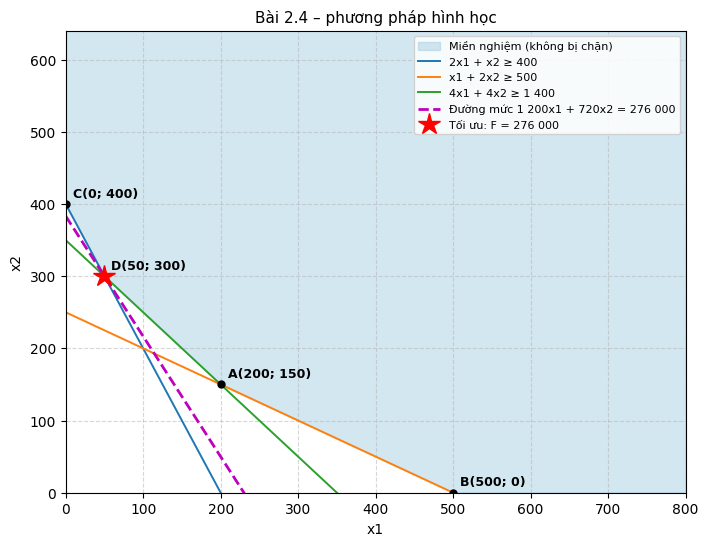

In [6]:
bt24 = giai("Bài 2.4 – phương pháp hình học", muc_tieu=(1200, 720), loai="min",
            rang_buoc=[(2, 1, ">=", 400),
                       (1, 2, ">=", 500),
                       (4, 4, ">=", 1400)],
            bien=("x1", "x2"), don_vi="đồng")

In [ ]:
# Kéo thanh trượt k: đường mức tịnh tiến song song; đỉnh cuối cùng đường mức chạm miền nghiệm (khi k giảm) là điểm tối ưu
tuong_tac(bt24)

<a name="doingau"></a>

### 4.2. Phương pháp đơn hình đối ngẫu

Nhân hai vế các ràng buộc $\ge$ với $-1$ rồi thêm biến bù $x_3, x_4, x_5$:
$$-2x_1 - x_2 + x_3 = -400,\quad -x_1 - 2x_2 + x_4 = -500,\quad -4x_1 - 4x_2 + x_5 = -1400.$$
Cơ sở $\{x_3, x_4, x_5\}$ có $\Delta_j = -c_j \le 0$ (đã thoả dấu hiệu tối ưu) nhưng phương án âm ⇒ dùng **đơn hình đối ngẫu**: không cần biến nhân tạo.

In [8]:
c = [1200, 720, 0, 0, 0]
A = [[-2, -1, 1, 0, 0],
     [-1, -2, 0, 1, 0],
     [-4, -4, 0, 0, 1]]
b = [-400, -500, -1400]
kq = don_hinh_doi_ngau(c, A, b, co_so=[2, 3, 4], ten_bai="Bài 2.4 – đơn hình đối ngẫu", so_bien_goc=2)
kiem_chung([1200, 720], A_ub=[[-2, -1], [-1, -2], [-4, -4]], b_ub=[-400, -500, -1400], ket_qua=kq[1], ten_bai="Bài 2.4");

BÀI 2.4 – ĐƠN HÌNH ĐỐI NGẪU

--- BẢNG 1 ---
Cơ sở cB Phương án    x1   x2 x3 x4 x5
   x3  0      -400    -2   -1  1  0  0
   x4  0      -500    -1   -2  0  1  0
   x5  0     -1400    -4   -4  0  0  1
   Δj            0 -1200 -720  0  0  0
-> Biến ra: x5 (b = -1400 âm nhất).  Tỉ số Δj/a_rj: x1: (-1200)/(-4) = 300, x2: (-720)/(-4) = 180
-> Biến vào: x2.  Phần tử trục: -4

--- BẢNG 2 ---
Cơ sở  cB Phương án   x1 x2 x3 x4   x5
   x3   0       -50   -1  0  1  0 -1/4
   x4   0       200    1  0  0  1 -1/2
   x2 720       350    1  1  0  0 -1/4
   Δj        252000 -480  0  0  0 -180
-> Biến ra: x3 (b = -50 âm nhất).  Tỉ số Δj/a_rj: x1: (-480)/(-1) = 480, x5: (-180)/(-1/4) = 720
-> Biến vào: x1.  Phần tử trục: -1

--- BẢNG 3 ---
Cơ sở   cB Phương án x1 x2   x3 x4   x5
   x1 1200        50  1  0   -1  0  1/4
   x4    0       150  0  0    1  1 -3/4
   x2  720       300  0  1    1  0 -1/2
   Δj         276000  0  0 -480  0  -60
=> Mọi phương án b_i ≥ 0 và mọi Δj ≤ 0: phương án TỐI ƯU.

----------

<a name="bigm24"></a>

### 4.3. Phương pháp Big-M

Dạng chính tắc với biến bù (trừ) $x_3, x_4, x_5$ và biến nhân tạo $x_6, x_7, x_8$:
$$2x_1 + x_2 - x_3 + x_6 = 400,\quad x_1 + 2x_2 - x_4 + x_7 = 500,\quad 4x_1 + 4x_2 - x_5 + x_8 = 1400,$$
$$f_M = 1200x_1 + 720x_2 + M(x_6 + x_7 + x_8) \to \min.$$

In [9]:
c = [1200, 720, 0, 0, 0, M, M, M]
A = [[2, 1, -1,  0,  0, 1, 0, 0],
     [1, 2,  0, -1,  0, 0, 1, 0],
     [4, 4,  0,  0, -1, 0, 0, 1]]
b = [400, 500, 1400]
kq = don_hinh(c, A, b, co_so=[5, 6, 7], ten_bai="Bài 2.4 – Big-M", nhan_tao=[5, 6, 7], so_bien_goc=2)

BÀI 2.4 – BIG-M

--- BẢNG 1 ---
Cơ sở cB Phương án      x1     x2 x3 x4 x5 x6 x7 x8
   x6  M       400       2      1 -1  0  0  1  0  0
   x7  M       500       1      2  0 -1  0  0  1  0
   x8  M      1400       4      4  0  0 -1  0  0  1
   Δj        2300M 7M-1200 7M-720 -M -M -M  0  0  0
-> Biến vào: x2 (Δ = 7M-720).  Tỉ số θ: x6: 400/1 = 400, x7: 500/2 = 250, x8: 1400/4 = 350
-> Biến ra: x7.  Phần tử trục: 2 (dòng 2, cột x2)

--- BẢNG 2 ---
Cơ sở  cB   Phương án       x1 x2 x3       x4 x5 x6        x7 x8
   x6   M         150      3/2  0 -1      1/2  0  1      -1/2  0
   x2 720         250      1/2  1  0     -1/2  0  0       1/2  0
   x8   M         400        2  0  0        2 -1  0        -2  1
   Δj     550M+180000 7/2M-840  0 -M 5/2M-360 -M  0 -7/2M+360  0
-> Biến vào: x1 (Δ = 7/2M-840).  Tỉ số θ: x6: 150/(3/2) = 100, x2: 250/(1/2) = 500, x8: 400/2 = 200
-> Biến ra: x6.  Phần tử trục: 3/2 (dòng 1, cột x1)

--- BẢNG 3 ---
Cơ sở   cB   Phương án x1 x2       x3      x4 x5        x6

<a name="haipha"></a>

### 4.4. Phương pháp hai pha

**Pha 1:** $w = x_6 + x_7 + x_8 \to \min$. Nếu $w_{min} > 0$ ⇒ bài toán gốc vô nghiệm; nếu $w_{min} = 0$ ⇒ bỏ các cột nhân tạo, sang **Pha 2** giải với hàm mục tiêu gốc.

*Nhận xét:* Pha 1 kết thúc tại phương án $(200;\,150)$ — chính là **đỉnh A** trong hình ở Mục 4.1; Pha 2 đi tiếp sang **đỉnh D** $(50;\,300)$. Đây là minh hoạ trực quan cho việc đơn hình “đi dọc các đỉnh” của miền nghiệm.

In [10]:
c = [1200, 720, 0, 0, 0, 0, 0, 0]
A = [[2, 1, -1,  0,  0, 1, 0, 0],
     [1, 2,  0, -1,  0, 0, 1, 0],
     [4, 4,  0,  0, -1, 0, 0, 1]]
b = [400, 500, 1400]
kq = hai_pha(c, A, b, co_so=[5, 6, 7], nhan_tao=[5, 6, 7], ten_bai="Bài 2.4 – hai pha", so_bien_goc=2)

BÀI 2.4 – HAI PHA – PHA 1: min w = x6 + x7 + x8

--- BẢNG 1 ---
Cơ sở cB Phương án x1 x2 x3 x4 x5 x6 x7 x8
   x6  1       400  2  1 -1  0  0  1  0  0
   x7  1       500  1  2  0 -1  0  0  1  0
   x8  1      1400  4  4  0  0 -1  0  0  1
   Δj         2300  7  7 -1 -1 -1  0  0  0
-> Biến vào: x1 (Δ = 7).  Tỉ số θ: x6: 400/2 = 200, x7: 500/1 = 500, x8: 1400/4 = 350
-> Biến ra: x6.  Phần tử trục: 2 (dòng 1, cột x1)

--- BẢNG 2 ---
Cơ sở cB Phương án x1  x2   x3 x4 x5   x6 x7 x8
   x1  0       200  1 1/2 -1/2  0  0  1/2  0  0
   x7  1       300  0 3/2  1/2 -1  0 -1/2  1  0
   x8  1       600  0   2    2  0 -1   -2  0  1
   Δj          900  0 7/2  5/2 -1 -1 -7/2  0  0
-> Biến vào: x2 (Δ = 7/2).  Tỉ số θ: x1: 200/(1/2) = 400, x7: 300/(3/2) = 200, x8: 600/2 = 300
-> Biến ra: x7.  Phần tử trục: 3/2 (dòng 2, cột x2)

--- BẢNG 3 ---
Cơ sở cB Phương án x1 x2   x3   x4 x5   x6   x7 x8
   x1  0       100  1  0 -2/3  1/3  0  2/3 -1/3  0
   x2  0       200  0  1  1/3 -2/3  0 -1/3  2/3  0
   x8  1     

<a name="sosanh"></a>

### 4.5. So sánh bốn phương pháp

| Phương pháp | Cần biến nhân tạo? | Số bảng / bước | Ưu điểm | Hạn chế |
|---|---|---|---|---|
| Hình học | Không | 4 đỉnh | Trực quan, phù hợp THPT | Chỉ dùng cho 2 ẩn |
| Đơn hình đối ngẫu | Không | 3 bảng | Gọn nhất khi mọi ràng buộc dạng $\ge$ và $c_j \ge 0$ | Cần bảng xuất phát có $\Delta_j \le 0$ |
| Big-M | Có (3) | 4 bảng | Một pha duy nhất | $\Delta_j$ chứa $M$, tính toán cồng kềnh |
| Hai pha | Có (3) | 4 + 2 bảng | Tách bạch: tìm phương án rồi tối ưu | Dài hơn |

Cả bốn phương pháp đều cho $x_1 = 50,\ x_2 = 300,\ f_{min} = 276\,000$ đồng.

<a name="ghichu"></a>

## 5. Ghi chú phương pháp

**Bài toán min:** $\Delta_j = c_B A_j - c_j$; tối ưu khi mọi $\Delta_j \le 0$. Biến vào: $\Delta_j > 0$ lớn nhất; biến ra: tỉ số $\theta_i = b_i / a_{is}$ nhỏ nhất với $a_{is} > 0$. Nếu có $\Delta_s > 0$ mà cột $s$ không có phần tử dương ⇒ hàm mục tiêu không bị chặn dưới. (Bài toán max: đổi thành min của $-f$.)

**Big-M:** $M$ được xử lý như **ký hiệu**: mỗi số có dạng $aM + b$, so sánh theo $a$ trước rồi đến $b$. Nếu bảng tối ưu còn biến nhân tạo dương ⇒ bài toán gốc **vô nghiệm**.

**Hai pha:** Pha 1 cực tiểu tổng biến nhân tạo. $w_{min} > 0$ ⇒ vô nghiệm. Nếu biến nhân tạo còn trong cơ sở ở mức 0, xoay để đưa một biến thật vào (hoặc bỏ ràng buộc thừa) rồi sang Pha 2.

**Đơn hình đối ngẫu:** dùng khi bảng đã thoả $\Delta_j \le 0$ nhưng có $b_i < 0$. Biến ra: dòng có $b_r$ âm nhất; biến vào: cột có $a_{rj} < 0$ với tỉ số $\Delta_j / a_{rj}$ nhỏ nhất; nếu dòng $r$ không có $a_{rj} < 0$ ⇒ vô nghiệm.

**Chống xoay vòng:** sau 100 vòng lặp, bộ giải tự chuyển sang quy tắc Bland (chọn biến vào có chỉ số nhỏ nhất).

**Phương pháp hình học:** nếu miền nghiệm bị chặn, $f$ luôn đạt GTLN, GTNN tại đỉnh. Nếu miền **không bị chặn**, phải xét thêm hướng dịch chuyển của đường mức: có thể có hoặc không có giá trị tối ưu.

---
## 📝 Góp ý sau khi sử dụng

Cảm ơn bạn đã dùng thử học liệu! Xin dành khoảng **5 phút** điền **[Phiếu đánh giá mức độ đáp ứng của sản phẩm mô phỏng GeoGebra và Python](https://docs.google.com/forms/d/e/1FAIpQLScNqxvL5WIb8PxsOMvBbOrmmGTwV56bMyRV8-Nb_2Zvj225iw/viewform)** (không bắt buộc ghi họ tên). Ý kiến của bạn giúp nhóm hoàn thiện sản phẩm.

👉 **https://docs.google.com/forms/d/e/1FAIpQLScNqxvL5WIb8PxsOMvBbOrmmGTwV56bMyRV8-Nb_2Zvj225iw/viewform**

*Đề tài NCKH sinh viên TSV2026-211 – Trường Sư phạm, Đại học Cần Thơ · Kho học liệu: https://github.com/VuiPhamCTU/QHTT-GeoGebra-Python*